In [1]:
# This notebook can be used to process flight files and generate pickled files of correlator+drone data

In [2]:
## First import general packages for running python analysis:
import os, h5py, datetime,pytz,pickle, yaml, sys
import numpy as np
from matplotlib.pyplot import *
from matplotlib import pyplot as plt

## Then import the beamcals module, use forked repository (not original):
sys.path.insert(0, '../classes/')
import corr, concat, drone
import plotting_utils as pu
import fitting_utils as fu
import geometry_utils as gu
import time_utils as tu
import site_utils as si
gbosite=si.Site('../metadata/GBO_DNS_config.npz')

# Define any channels, etc, and directories for this flight analysis

#config_directory="  "
maindir = '/hirax/DNS_freespace/TONE_july_2025/'
dronedir = maindir+'processed_flight_records/'
cdir = maindir+'TONE_iceboard_files/corr_data/'
gdir = maindir+'TONE_iceboard_files/digital_gains/' 

# define which channels in the data files are useful
crmap = [0,3,4,6,7,8,9]
chnames = ['EW_D5_auto','EW_D5_cr','NS_D5_auto','NS_D5_cr','NS_D8_auto','NS_D8_cr','ref_auto']

# from crmap, which indices are autos, which indices are ref crosses
autos = [0,2,4,6]
crosses = [1,3,5]


# define default 'good' frequency for plotting
f_ind = 300 
freqs = np.arange(800,400,-400./1024)
print(freqs[f_ind])

###################
#### FUNCTIONS ####
###################

def get_mag_phase(power0):
    """
    # return magnitude and phase in degrees of correlations
    """
    return np.absolute(power0), np.rad2deg(np.angle(power0))



682.8125


## 1.Load in RFI data set of your choice

In [35]:
with open('../metadata/DNS_GBO_flights_forscripts_LBN.yaml', 'r') as fff:
    documents = yaml.safe_load(fff)
flights = documents["flight_info"]["flights"]
descrip = documents["flight_info"]["desc"]
polar = documents["flight_info"]["pols"]

for f,fly in enumerate(flights):
    print(f,flights[f],polar[f])

# airdata files are not very easily subscriptable, 
# cluge for now by knowing which flight order is in the yaml
f = 0


fly = flights[f]
tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
cdat = documents["flight_info"]["cdats"][f]
tclb = documents["flight_info"]["tclbs"][f]
tcub = documents["flight_info"]["tcubs"][f]
fmax = documents["flight_info"]["fmaxes"][f]
fmin = documents["flight_info"]["fmins"][f]


ddir = cdir+cdat+'/corr/'
di = os.listdir(ddir)[0]
datadir = ddir+str(di)+'/'
gaindir = gdir+cdat+'_digitalgain/'
print('Using data directory: ',datadir)
print('Using gain directory: ',gaindir)

print(fly, tub, tlb, tclb, tcub, cdat,fmin,fmax)

0 Jul-14th-2025-10-14AM-Flight-Airdata.csv N
1 Jul-17th-2025-12-16PM-Flight-Airdata.csv N
2 Jul-17th-2025-12-47PM-Flight-Airdata.csv N
3 Jul-17th-2025-01-51PM-Flight-Airdata.csv E
4 Jul-17th-2025-04-07PM-Flight-Airdata.csv E
5 Jul-17th-2025-04-39PM-Flight-Airdata.csv N
6 Jul-17th-2025-07-56PM-Flight-Airdata.csv N
7 Jul-17th-2025-08-47PM-Flight-Airdata.csv N
8 Jul-18th-2025-08-33PM-Flight-Airdata.csv N
9 Jul-19th-2025-02-39PM-Flight-Airdata.csv E
Using data directory:  /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250714T135821Z_WVUc52/corr/20250714T135918Z/
Using gain directory:  /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/digital_gains/20250714T135821Z_WVUc52_digitalgain/
Jul-14th-2025-10-14AM-Flight-Airdata.csv -1 0 0 -1 20250714T135821Z_WVUc52 94 229


Initializing drone data via Airdata.csv routine: Jul-14th-2025-10-14AM-Flight-Airdata.csv
  --> Skipping rows 1 to 499 to eliminate NAN values
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.
DONE reading in drone data
2025-07-14 14:16:14.900000+00:00 2025-07-14 14:40:22.900000+00:00


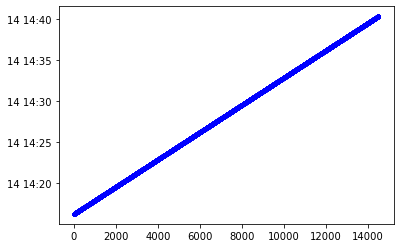

plotting drone coordinates for all time samples:
overplotting drone coordinates for t_cut samples: [0:-1]


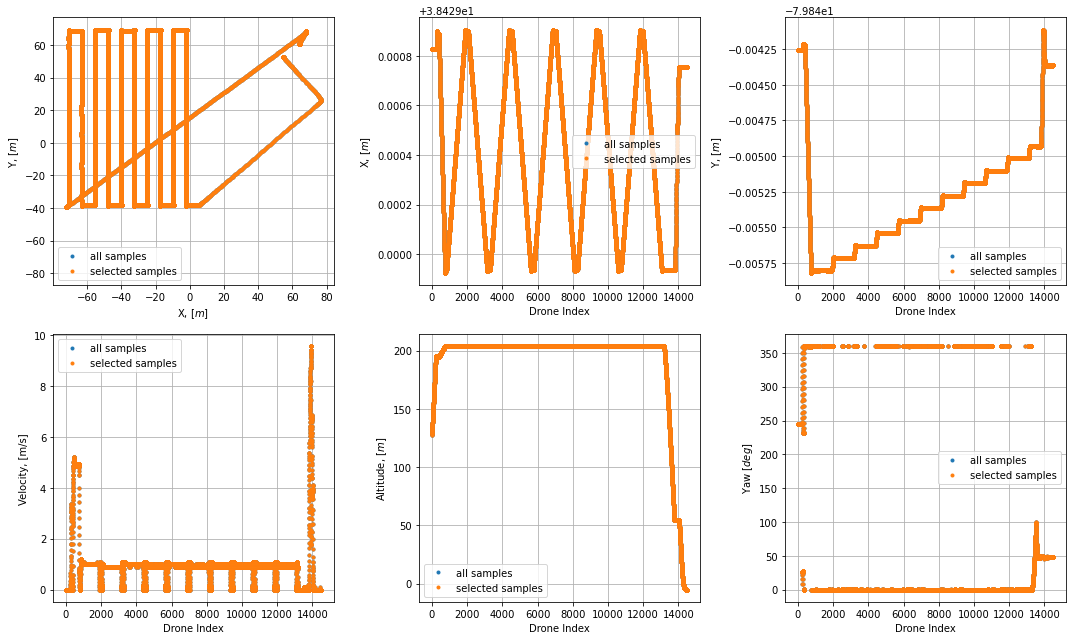

In [36]:
dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=fly,site_class=gbosite,tlb=tlb,tub=tub)

print('DONE reading in drone data')
print(dronedata.t_arr_datetime[0], dronedata.t_arr_datetime[-1])

plt.plot(dronedata.t_arr_datetime,'b.',label='drone')
plt.show()

pu.Plot_Drone_Coordinates(dronedata,coo='xy')#,t_bounds=[tlb,tub])
#pu.Plot_Drone_Coordinates(dronetest0825,coo='xy',t_bounds=[tlb,tub])

start time:  2025-09-24 15:59:07.523481
Initializing Correlator Class using:
  --> /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250719T000859Z_WVUc52/corr/20250719T000955Z/
  --> Arrays initialized with shape (141, 256, 1024, 4)
Assigning array values by reading in data files:
  --> Loading File: 0140/0140
  --> Finished. Reshaping arrays.
end time:  2025-09-24 16:01:37.801746


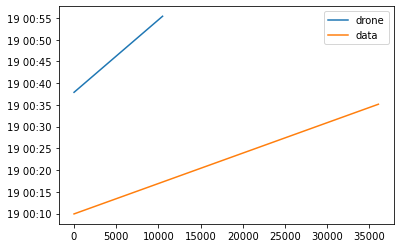

In [15]:
# First, look at data BEFORE the drone flight - let's not load gains so we can look at corr saturation
print('start time: ', datetime.datetime.now())

corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=False,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[0,int(fmin)])

    
print('end time: ', datetime.datetime.now())

# putting checks in one cell now that I know I've mostly figured out the flight/corr file correspondence
# This checks I copied and pasted ok :)

## plot their datetime arrays to check overlap:

plot(dronedata.t_arr_datetime,label='drone')
plot(corrdata.t_arr_datetime,label='data')
legend()


In [ ]:
corrdata.V_cross.shape

# plot waterfalls of autos
vmin=60000
vmax=120000
for j in autos:
    fig=figure(figsize=(16,8))
    plt.imshow(corrdata.V_cross[:,:,j].real,aspect='auto',vmin=vmin,vmax=vmax)
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j])
    plt.colorbar()
    plt.show()

In [ ]:
3E8/10E6

In [ ]:
mean_perch = np.median(abs(corrdata.V_cross),axis=0) # time, freq,ch
max_perch = np.max(abs(corrdata.V_cross),axis=0) # time, freq,ch

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,mean_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.show()

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,max_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.show()

start time:  2025-09-24 16:38:39.432799
Initializing Correlator Class using:
  --> /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250714T135821Z_WVUc52/corr/20250714T135918Z/
  --> Arrays initialized with shape (135, 256, 1024, 4)
Assigning array values by reading in data files:
  --> Loading File: 0228/0228
  --> Finished. Reshaping arrays.
end time:  2025-09-24 16:39:19.363844


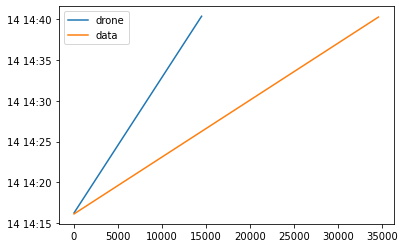

In [37]:
# First, look at data BEFORE the drone flight - let's not load gains so we can look at corr saturation
print('start time: ', datetime.datetime.now())

corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=False,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[int(fmin),int(fmax)])

    
print('end time: ', datetime.datetime.now())

# putting checks in one cell now that I know I've mostly figured out the flight/corr file correspondence
# This checks I copied and pasted ok :)

## plot their datetime arrays to check overlap:

plot(dronedata.t_arr_datetime,label='drone')
plot(corrdata.t_arr_datetime,label='data')
legend()


In [38]:
# Match drone and correlator data together, and plot a few frequencies

concatdata=concat.CONCAT(CORRDATCLASS=corrdata,DRONEDATCLASS=dronedata,\
                             load_yaml=False,traceback=False,save_traceback=False)

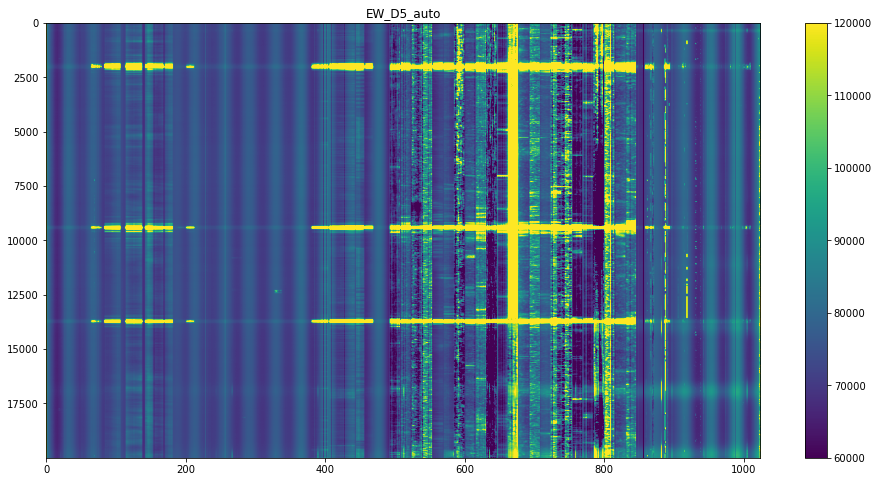

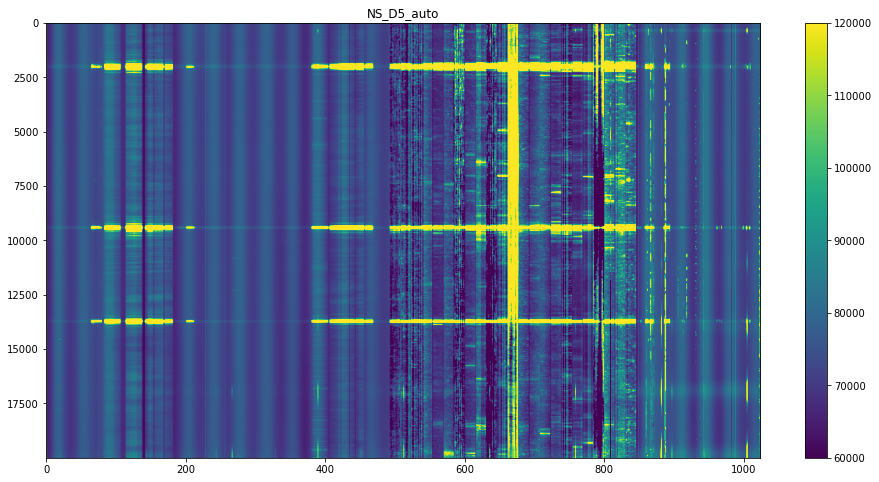

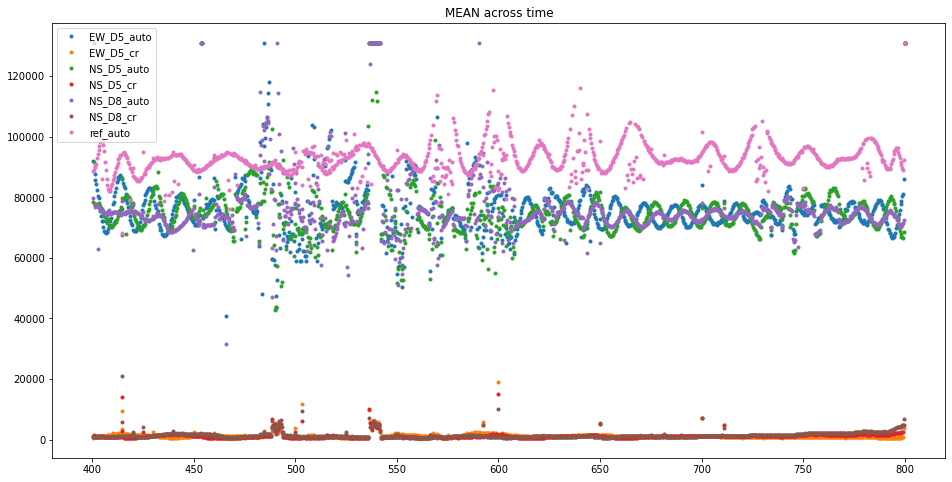

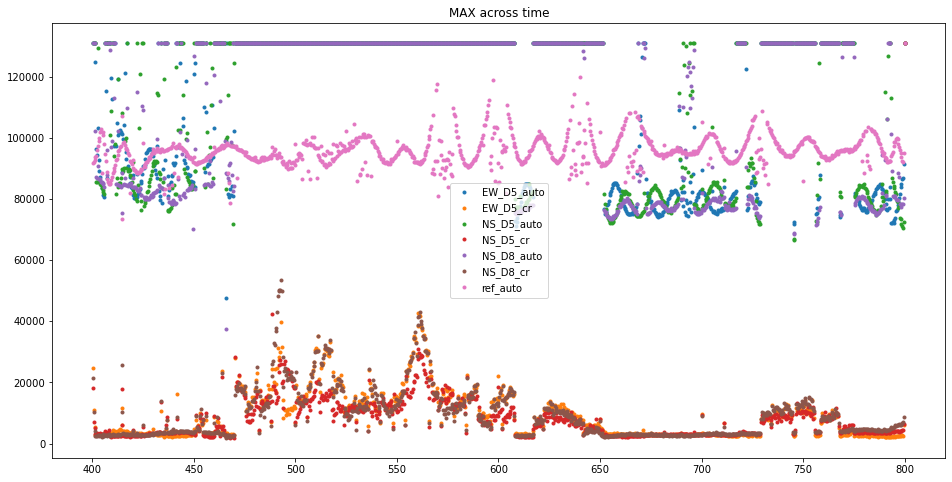

In [39]:
corrdata.V_cross.shape

# plot waterfalls of autos
vmin=60000
vmax=120000

tmin = 0
tmax=20000
for j in autos[0:2]:
    fig=figure(figsize=(16,8))
    plt.imshow(concatdata.V_cross[tmin:tmax,:,j].real,
               aspect='auto',vmin=vmin,vmax=vmax,
               #extent=[freqs[0],freqs[1023],tmax,tmin]
              )
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j])
    plt.colorbar()
    plt.show()

mean_perch = np.median(abs(concatdata.V_cross[tmin:tmax,:,:]),axis=0) # time, freq,ch
max_perch = np.max(abs(concatdata.V_cross[tmin:tmax,:,:]),axis=0) # time, freq,ch

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,mean_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.title('MEAN across time')
plt.show()

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,max_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.title('MAX across time')
plt.show()

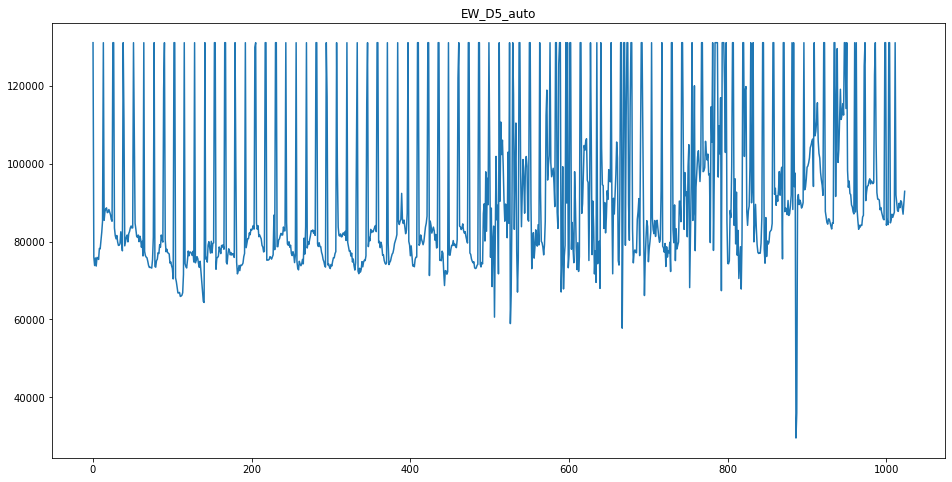

In [12]:

vmin=60000
vmax=120000

tmin = 13600
tmax=13800
for j in autos[0:1]:
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.V_cross[11125,:,j].real)
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j])
    plt.show()

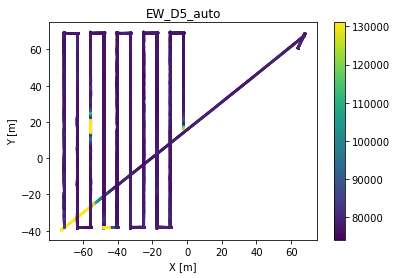

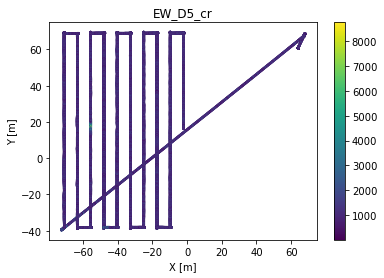

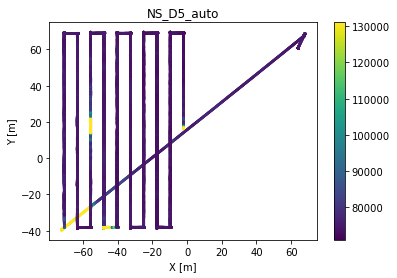

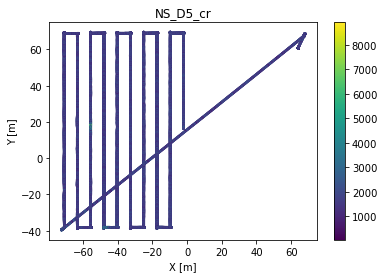

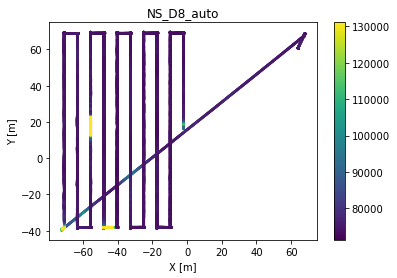

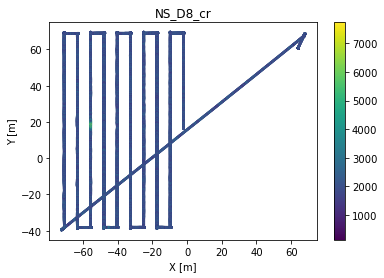

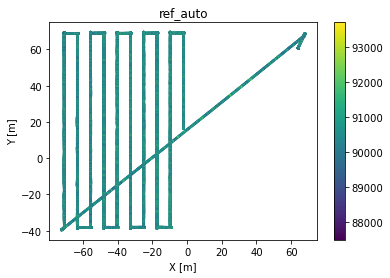

In [41]:
f_ind = 102

tmin = 0
tmax=30000

for j in np.arange(0,len(crmap)):
    plt.scatter(concatdata.drone_xyz_LC_interp[tmin:tmax,0],concatdata.drone_xyz_LC_interp[tmin:tmax,1],
                c=abs(concatdata.V_cross[tmin:tmax,f_ind,j]),s=3)
    plt.colorbar()
    plt.xlabel('X [m]')
    plt.ylabel('Y [m]')
    plt.title(chnames[j])
    plt.show()
f_ind = 300

In [ ]:

mean_perch = np.median(abs(concatdata.V_cross),axis=0) # time, freq,ch
max_perch = np.max(abs(concatdata.V_cross),axis=0) # time, freq,ch

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,mean_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.show()

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,max_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.show()

In [ ]:
# lets check gain application
print(gaindir)
gainfile=os.listdir(gaindir)[0]
fg = h5py.File(gaindir+gainfile, 'r')
gain_coeffs=fg['gain_coeff'][0] 
gain_exp=fg['gain_exp'][0]
digital_gain=fg['gain_coeff'][0] 
digital_gain*=np.power(2,fg['gain_exp'][0])[np.newaxis,:]

for j in np.arange(0,len(digital_gain[0,:])):
    plt.semilogy(freqs,digital_gain[:,j],label=str(j))
plt.legend()
plt.show()

